# Workshop 1 — Análisis exploratorio de datos (EDA)
### Anime Recommendations Database

**Equipo:** Cristian Cabezas, Mateo Lopera y Juanes Villada

En este notebook aplicamos el ciclo completo de exploración de datos: reconocimiento inicial, limpieza, análisis descriptivo y visualización. Trabajamos con `anime.csv`, uno de los archivos del conjunto de datos **Anime Recommendations Database** de Kaggle.

## Fase 1 — Reconocimiento inicial

El conjunto de datos asignado reúne información de MyAnimeList. Según la [documentación de Kaggle](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database), contiene preferencias de **73.516 usuarios** sobre **12.294 animes** y está dividido en dos archivos:

- **`anime.csv`**: un registro por anime, con información descriptiva del catálogo.
- **`rating.csv`**: aproximadamente 7,8 millones de registros de usuarios y animes. El valor `-1` indica que el usuario vio el anime, pero no le asignó una calificación.

Para este taller usamos la **versión 1 de `anime.csv`**, porque incluye las variables necesarias para el EDA solicitado. `rating.csv` queda fuera del análisis y solo se considera como una posible fuente para trabajos futuros.

**Diccionario de datos**

| Columna | Tipo esperado | Descripción |
|---|---|---|
| `anime_id` | numérico entero | Identificador único del anime en MyAnimeList |
| `name` | texto | Nombre completo del anime |
| `genre` | texto multietiqueta | Géneros separados por comas |
| `type` | categórica | Formato: Movie, TV, OVA, Special, ONA o Music |
| `episodes` | numérico entero | Número de episodios; la documentación indica 1 para películas |
| `rating` | numérico decimal | Calificación promedio sobre 10 |
| `members` | numérico entero | Miembros de la comunidad asociados al grupo del anime |

Antes de comenzar, definimos dos límites de interpretación:

- `members` no representa visualizaciones, votos ni usuarios únicos. Lo usamos únicamente como una aproximación a la popularidad dentro de esta versión del conjunto de datos.
- `rating` es un promedio, pero `anime.csv` no informa cuántas calificaciones lo sostienen. Por eso no podemos evaluar su estabilidad usando solamente este archivo.

Nuestro objetivo es describir asociaciones entre las variables, no demostrar relaciones causales.

In [1]:
# Bloque 1: importar librerías, localizar el archivo y validar la fuente
from pathlib import Path
import html
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATASET_HANDLE = "CooperUnion/anime-recommendations-database/versions/1"
ARCHIVO = "anime.csv"
COLUMNAS_ESPERADAS = [
    "anime_id", "name", "genre", "type", "episodes", "rating", "members"
]

ruta_local = Path(ARCHIVO)

if ruta_local.exists():
    ruta_csv = ruta_local
    print("Usando el archivo local:", ruta_csv)
else:
    try:
        import kagglehub

        ruta_csv = Path(
            kagglehub.dataset_download(DATASET_HANDLE, path=ARCHIVO)
        )
        print("Archivo descargado desde Kaggle:", ruta_csv)
    except Exception as error_descarga:
        if "google.colab" in sys.modules:
            from google.colab import files

            print("No fue posible descargar el archivo. Súbalo manualmente.")
            archivos_subidos = files.upload()
            if ARCHIVO not in archivos_subidos:
                raise FileNotFoundError(
                    f"No se encontró {ARCHIVO} entre los archivos subidos."
                ) from error_descarga
            ruta_csv = Path(ARCHIVO)
        else:
            raise RuntimeError(
                "No fue posible obtener anime.csv. Instale kagglehub o ubique "
                "anime.csv en la misma carpeta del notebook."
            ) from error_descarga

df_original = pd.read_csv(ruta_csv)

if list(df_original.columns) != COLUMNAS_ESPERADAS:
    raise ValueError(
        f"Columnas inesperadas: {list(df_original.columns)}"
    )
if df_original.shape != (12294, 7):
    raise ValueError(
        f"Tamaño inesperado: {df_original.shape}. Se esperaba (12294, 7)."
    )
if not df_original["anime_id"].is_unique:
    raise ValueError("anime_id debería ser único y se encontraron repeticiones.")

# Conservamos una copia intacta y trabajamos sobre un dataframe independiente.
df = df_original.copy()

print("Tamaño validado:", df_original.shape)
df_original.head()

Usando el archivo local: anime.csv
Tamaño validado: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [2]:
# Primeras y últimas cinco filas
print("Primeras cinco filas:")
display(df_original.head())

print("Últimas cinco filas:")
display(df_original.tail())

print("Filas y columnas:", df_original.shape)

Primeras cinco filas:


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


Últimas cinco filas:


,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142


Filas y columnas: (12294, 7)


In [3]:
df_original.info()
print("\nTipos de datos:\n", df_original.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB

Tipos de datos:
 anime_id      int64
name            str
genre           str
type            str
episodes        str
rating      float64
members       int64
dtype: object


A partir de `.info()` y `.dtypes` clasificamos las columnas así:

- **Numéricas:** `rating`, `members` y `anime_id`. Aunque `anime_id` es numérica, funciona como identificador y no como medida. `episodes` debería ser numérica, pero pandas la reconoce inicialmente como texto por la presencia de valores `"Unknown"`.
- **Categóricas o de texto:** `type`, `genre` y `name`. `genre` es multietiqueta porque un anime puede pertenecer a varios géneros.
- **De fecha:** ninguna. El archivo no incluye año, temporada ni fecha de emisión; por esta razón, en el punto 21 usaremos el diagrama de caja alternativo permitido por el enunciado.

También observamos menos valores no nulos en `genre`, `type` y `rating`, por lo que estas columnas requieren una revisión en la fase de limpieza.

In [4]:
df_original.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


Del `.describe()` destacamos los siguientes resultados:

- La calificación (`rating`) tiene una media de **6,47**, una mediana de **6,57** y una desviación estándar de **1,03**. Sus valores van de 1,67 a 10,00, aunque la mayor parte se concentra en la zona media-alta observada, cerca de 6,5.
- En `members`, la media es **18.071**, mientras que la mediana es **1.550**. Esta diferencia muestra que la distribución está fuertemente sesgada hacia la derecha.
- La desviación estándar de `members` es **54.821**, casi tres veces su media, y el máximo supera el millón. Estos resultados sugieren que unos pocos títulos tienen valores mucho mayores que el resto.

No interpretamos los estadísticos de `anime_id`, porque los valores de un identificador no tienen un significado analítico útil.

In [5]:
# Convertimos una columna numérica a un array de NumPy.
members_array = df_original["members"].to_numpy()

print("Media con NumPy:", np.mean(members_array))
print("Mediana con NumPy:", np.median(members_array))
print("Desviación estándar con NumPy:", np.std(members_array))

Media con NumPy: 18071.33886448674
Mediana con NumPy: 1550.0
Desviación estándar con NumPy: 54818.447309169394


Con NumPy obtuvimos una media de **18.071,34**, una mediana de **1.550** y una desviación estándar de **54.818,45** para `members`. La mediana es mucho menor que la media, lo que confirma la influencia de los títulos con valores altos.

La pequeña diferencia entre `np.std()` (**54.818,45**) y la desviación mostrada por pandas (**54.820,68**) no es un error. NumPy calcula por defecto la desviación poblacional, dividiendo entre *n*, mientras que pandas usa la desviación muestral, dividiendo entre *n − 1*.

## Fase 2 — Limpieza de datos

In [6]:
# Valores nulos reconocidos inicialmente por pandas
nulos_iniciales = df_original.isnull().sum()
porcentaje_nulos_inicial = (nulos_iniciales / len(df_original)) * 100

resumen_nulos_inicial = pd.DataFrame({
    "Nulos": nulos_iniciales,
    "Porcentaje (%)": porcentaje_nulos_inicial.round(2),
})
resumen_nulos_inicial

,Nulos,Porcentaje (%)
anime_id,0,0.00
name,0,0.00
genre,62,0.50
type,25,0.20
episodes,0,0.00
rating,230,1.87
members,0,0.00


In [7]:
# Convertimos episodes a numérica; "Unknown" pasa a ser un valor nulo.
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")
episodios_desconocidos_original = df["episodes"].isna()

nulos_actualizados = df.isnull().sum()
porcentaje_nulos_actualizado = (nulos_actualizados / len(df)) * 100
resumen_nulos_actualizado = pd.DataFrame({
    "Nulos": nulos_actualizados,
    "Porcentaje (%)": porcentaje_nulos_actualizado.round(2),
})

print("Nulos después de convertir episodes a numérica:")
display(resumen_nulos_actualizado)

Nulos después de convertir episodes a numérica:


,Nulos,Porcentaje (%)
anime_id,0,0.00
name,0,0.00
genre,62,0.50
type,25,0.20
episodes,340,2.77
rating,230,1.87
members,0,0.00


Después de convertir `episodes`, identificamos cuatro columnas con datos faltantes: `genre` (62; 0,50 %), `type` (25; 0,20 %), `rating` (230; 1,87 %) y `episodes` (340; 2,77 %).

Aplicamos la siguiente estrategia:

- **`genre`:** usamos `"Unknown"` para conservar el registro y dejar visible que el género no estaba disponible.
- **`type` y `rating`:** excluimos las filas incompletas del conjunto analítico. No sería metodológicamente válido inventar el formato o la calificación. Antes de excluirlas, comparamos su perfil con el de las filas conservadas.
- **`episodes`:** después de definir el conjunto analítico, imputamos los faltantes con la mediana de su propio `type`. Esta opción respeta mejor las diferencias entre una serie de TV, una película y otros formatos que una mediana global.

Las conclusiones posteriores se refieren a los animes que tienen `type` y `rating` disponibles.

In [8]:
# 1. Conservamos los géneros desconocidos con una etiqueta explícita.
df["genre"] = df["genre"].fillna("Unknown")

# 2. Identificamos las filas que no pueden entrar al análisis de type y rating.
filas_excluidas = df["type"].isna() | df["rating"].isna()
type_nulo_tambien_sin_rating = df.loc[df["type"].isna(), "rating"].isna().all()

comparacion_exclusion = pd.DataFrame({
    "Grupo": ["Filas conservadas", "Filas excluidas"],
    "Cantidad": [(~filas_excluidas).sum(), filas_excluidas.sum()],
    "members promedio": [
        df.loc[~filas_excluidas, "members"].mean(),
        df.loc[filas_excluidas, "members"].mean(),
    ],
    "members mediana": [
        df.loc[~filas_excluidas, "members"].median(),
        df.loc[filas_excluidas, "members"].median(),
    ],
    "episodes desconocidos (%)": [
        episodios_desconocidos_original.loc[~filas_excluidas].mean() * 100,
        episodios_desconocidos_original.loc[filas_excluidas].mean() * 100,
    ],
})

print("Los 25 nulos de type también tienen rating nulo:", type_nulo_tambien_sin_rating)
display(comparacion_exclusion.round(2))

df = df.loc[~filas_excluidas].copy()

# 3. Imputamos episodes con la mediana correspondiente a cada type.
episodios_imputados = df["episodes"].isna()
medianas_episodes_por_type = df.groupby("type")["episodes"].median()
df["episodes"] = (
    df["episodes"]
    .fillna(df["type"].map(medianas_episodes_por_type))
    .astype("int64")
)

print("Medianas usadas para imputar episodes:")
display(medianas_episodes_por_type.astype(int).sort_index())
print("Filas excluidas por type/rating:", int(filas_excluidas.sum()))
print("Valores de episodes imputados en el conjunto analítico:", int(episodios_imputados.sum()))
print("Géneros Unknown en el conjunto analítico:", int((df["genre"] == "Unknown").sum()))
print("Nulos restantes:", int(df.isnull().sum().sum()))
print("Tamaño del conjunto analítico:", df.shape)

Los 25 nulos de type también tienen rating nulo: True


,Grupo,Cantidad,members promedio,members mediana,episodes desconocidos (%)
0,Filas conservadas,12064,18279.52,1539.0,1.56
1,Filas excluidas,230,7151.57,2049.0,66.09


Medianas usadas para imputar episodes:


type
Movie       1
Music       1
ONA         2
OVA         2
Special     1
TV         24
Name: episodes, dtype: int64

Filas excluidas por type/rating: 230
Valores de episodes imputados en el conjunto analítico: 188
Géneros Unknown en el conjunto analítico: 47
Nulos restantes: 0
Tamaño del conjunto analítico: (12064, 7)


El conjunto analítico quedó con **12.064 filas y 7 columnas**. Se excluyeron 230 registros: los 25 casos sin `type` también estaban dentro de los registros sin `rating`, por eso no se eliminaron 255 filas.

La comparación muestra que las filas excluidas tienen un perfil distinto: presentan un promedio menor de `members` y una proporción mucho mayor de episodios desconocidos. Por esta razón, no afirmamos que su exclusión sea irrelevante; simplemente delimitamos el alcance de los resultados a los títulos con `type` y `rating` disponibles.

Después de la exclusión quedaron **188** valores faltantes en `episodes`. Se imputaron por tipo con estas medianas: TV 24; OVA y ONA 2; Movie, Special y Music 1. Finalmente, convertimos la columna a entero y verificamos que no quedaran nulos.

In [9]:
# Resumen numérico después de la limpieza
display(df.describe())

comprobaciones_episodes = pd.Series({
    "Títulos con 1 o 2 episodios": int(df["episodes"].isin([1, 2]).sum()),
    "Porcentaje con 1 o 2 episodios": df["episodes"].isin([1, 2]).mean() * 100,
    "Títulos con más de 100 episodios": int((df["episodes"] > 100).sum()),
    "Porcentaje con más de 100 episodios": (df["episodes"] > 100).mean() * 100,
})
print("Comprobaciones adicionales de episodes:")
display(comprobaciones_episodes.round(2))

,anime_id,episodes,rating,members
count,12064.000000,12064.000000,12064.000000,1.206400e+04
mean,13704.476044,12.468087,6.473902,1.827952e+04
std,11260.369521,46.663837,1.026746,5.527578e+04
min,1.000000,1.000000,1.670000,1.200000e+01
25%,3409.250000,1.000000,5.880000,2.210000e+02
50%,10004.000000,2.000000,6.570000,1.539000e+03
75%,23863.500000,12.000000,7.180000,9.485500e+03
max,34519.000000,1818.000000,10.000000,1.013917e+06


Comprobaciones adicionales de episodes:


Títulos con 1 o 2 episodios            6774.00
Porcentaje con 1 o 2 episodios           56.15
Títulos con más de 100 episodios        159.00
Porcentaje con más de 100 episodios       1.32
dtype: float64

Después de la limpieza, `episodes` tiene una media de **12,47**, una mediana de **2** y un máximo de **1.818**. En total, **6.774 títulos (56,15 %)** tienen uno o dos episodios, mientras que solo **159 (1,32 %)** superan los 100.

La diferencia entre media y mediana confirma que unas pocas series muy largas elevan el promedio. Esto justifica el uso de medianas por `type` para imputar: asignar 24 episodios a una serie de TV con dato faltante es más coherente que aplicar el mismo valor a todos los formatos.

`anime_id` aparece en `.describe()` porque es una columna numérica, pero sus estadísticos siguen sin tener una interpretación analítica útil.

In [10]:
# Revisión y normalización de columnas de texto
print("Valores únicos de type antes de normalizar:", df["type"].unique())
cambios_type = (df["type"] != df["type"].str.strip()).sum()
df["type"] = df["type"].str.strip()
print("Filas de type con espacios externos:", int(cambios_type))

patron_html = r"&[a-zA-Z]+;|&#[0-9]+;"
con_entidades = df["name"].str.contains(patron_html, regex=True, na=False)
ejemplos_nombres = pd.DataFrame({
    "Antes": df.loc[con_entidades, "name"].head(5).to_list()
})

df["name"] = df["name"].apply(html.unescape).str.strip()
ejemplos_nombres["Después"] = df.loc[con_entidades, "name"].head(5).to_list()

print("Nombres con entidades HTML antes de corregir:", int(con_entidades.sum()))
display(ejemplos_nombres)
print(
    "Nombres con entidades HTML después de corregir:",
    int(df["name"].str.contains(patron_html, regex=True, na=False).sum()),
)

generos_crudos = df["genre"].str.split(",").explode()
generos_limpios = generos_crudos.str.strip()
genre_antes = df["genre"].copy()
df["genre"] = df["genre"].apply(
    lambda texto: ", ".join(genero.strip() for genero in texto.split(","))
)

print("Géneros distintos sin strip():", int(generos_crudos.nunique()))
print("Géneros distintos después de strip():", int(generos_limpios.nunique()))
print("Filas de genre modificadas al normalizar:", int((genre_antes != df["genre"]).sum()))

Valores únicos de type antes de normalizar: <StringArray>
['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA']
Length: 6, dtype: str
Filas de type con espacios externos: 0
Nombres con entidades HTML antes de corregir: 286


,Antes,Después
0,Gintama&#039;,Gintama'
1,Gintama&#039;: Enchousen,Gintama': Enchousen
2,Kyoukai no Kanata Movie: I&#039;ll Be Here - M...,Kyoukai no Kanata Movie: I'll Be Here - Mirai-hen
3,Mahou Shoujo Lyrical Nanoha: The Movie 2nd A&#...,Mahou Shoujo Lyrical Nanoha: The Movie 2nd A's
4,Black Lagoon: Roberta&#039;s Blood Trail,Black Lagoon: Roberta's Blood Trail


Nombres con entidades HTML después de corregir: 0
Géneros distintos sin strip(): 83


Géneros distintos después de strip(): 44
Filas de genre modificadas al normalizar: 0


En las columnas de texto encontramos lo siguiente:

- **`type`:** sus seis categorías ya estaban escritas de forma consistente y no tenían espacios externos.
- **`name`:** 286 nombres contenían entidades HTML, por ejemplo `&#039;` en lugar de un apóstrofo. Las corregimos con `html.unescape()` y verificamos que no quedaran casos pendientes. Este patrón es compatible con texto almacenado desde una fuente HTML, pero el archivo no permite identificar con certeza el proceso que lo produjo.
- **`genre`:** la columna ya usaba de forma consistente el separador coma + espacio, por lo que la normalización no modificó filas. Sin embargo, al separar únicamente por coma aparecen 83 valores aparentes porque muchos conservan un espacio inicial; al aplicar `.strip()` obtenemos 43 géneros observados y la categoría `Unknown`, para 44 categorías en total. La limpieza evita errores en los conteos posteriores.

In [11]:
# Revisamos duplicados después de normalizar las columnas de texto.
duplicados_completos = df.duplicated().sum()
filas_antes = len(df)
df = df.drop_duplicates().copy()

print("Filas completamente duplicadas:", int(duplicados_completos))
print("Filas eliminadas por duplicado:", filas_antes - len(df))
print("anime_id repetidos:", int(df["anime_id"].duplicated().sum()))
print("Nombres repetidos:", int(df["name"].duplicated().sum()))

nombres_repetidos = (
    df[df["name"].duplicated(keep=False)]
    .sort_values("name")
    [["anime_id", "name", "type", "episodes", "rating", "members"]]
)
print("Registros que comparten nombre:")
display(nombres_repetidos)

Filas completamente duplicadas: 0
Filas eliminadas por duplicado: 0
anime_id repetidos: 0
Nombres repetidos: 2
Registros que comparten nombre:


,anime_id,name,type,episodes,rating,members
10140,22399,Saru Kani Gassen,OVA,1,5.23,62
10141,30059,Saru Kani Gassen,Movie,1,4.75,76
10193,33193,Shi Wan Ge Leng Xiaohua,ONA,12,6.67,114
10194,33195,Shi Wan Ge Leng Xiaohua,Movie,1,7.07,110


No encontramos filas completamente duplicadas ni `anime_id` repetidos. Sí aparecen dos nombres compartidos por pares de registros, pero cada fila tiene un identificador y atributos diferentes. Por lo tanto, no los eliminamos: compartir el nombre no es suficiente para concluir que un registro esté duplicado.

Hacer esta comprobación después de normalizar el texto permite detectar posibles coincidencias que antes podían estar ocultas por entidades HTML o espacios.

In [12]:
# Identificación manual de valores atípicos en members mediante el criterio IQR
q1_members = df["members"].quantile(0.25)
q3_members = df["members"].quantile(0.75)
iqr_members = q3_members - q1_members

limite_inferior_members = q1_members - 1.5 * iqr_members
limite_superior_members = q3_members + 1.5 * iqr_members

es_atipico_members = (
    (df["members"] < limite_inferior_members)
    | (df["members"] > limite_superior_members)
)
atipicos_members = df.loc[es_atipico_members]

porcentaje_titulos_atipicos = es_atipico_members.mean() * 100
porcentaje_suma_members_atipicos = (
    atipicos_members["members"].sum() / df["members"].sum() * 100
)

print(f"Q1={q1_members}, Q3={q3_members}, IQR={iqr_members}")
print(
    f"Límites IQR: [{limite_inferior_members}, {limite_superior_members}]"
)
print(
    "Títulos atípicos en members:",
    len(atipicos_members),
    f"({porcentaje_titulos_atipicos:.2f} %)"
)
print(
    "Participación en la suma de members:",
    f"{porcentaje_suma_members_atipicos:.2f} %"
)

atipicos_members[["name", "members", "rating"]].sort_values(
    "members", ascending=False
).head(10)

Q1=221.0, Q3=9485.5, IQR=9264.5
Límites IQR: [-13675.75, 23382.25]
Títulos atípicos en members: 1884 (15.62 %)
Participación en la suma de members: 85.44 %


,name,members,rating
40,Death Note,1013917,8.71
86,Shingeki no Kyojin,896229,8.54
804,Sword Art Online,893100,7.83
1,Fullmetal Alchemist: Brotherhood,793665,9.26
159,Angel Beats!,717796,8.39
19,Code Geass: Hangyaku no Lelouch,715151,8.83
841,Naruto,683297,7.81
3,Steins;Gate,673572,9.17
445,Mirai Nikki (TV),657190,8.07
131,Toradora!,633817,8.45


El límite superior del criterio IQR es **23.382,25**. Identificamos **1.884 títulos (15,62 %)** por encima de ese valor y ninguno por debajo, porque el límite inferior es negativo y `members` no puede tomar valores menores que cero.

No eliminamos estos casos. Son registros observados para los que no encontramos evidencia de error y permiten estudiar la concentración de la variable. En conjunto, el 15,62 % de títulos reúne el **85,44 % de la suma de `members`** del conjunto analítico.

Esta suma no representa personas únicas: un mismo usuario puede pertenecer a los grupos de varios animes. Por eso conviene comparar los títulos con valores altos de `members` frente al resto del catálogo. Las preguntas sobre consumo real requerirían variables que no aparecen en este archivo.

## Fase 3 — Exploración y análisis descriptivo

In [13]:
# Columna categórica 1: type
conteo_type = df["type"].value_counts()
print("Categorías distintas en type:", int(df["type"].nunique()))
print("Valores únicos:", df["type"].unique())
print("\nConteo por type:")
display(conteo_type)

# Columna categórica 2: genre, separada en géneros individuales
generos_individuales = df["genre"].str.split(", ").explode()
conteo_generos = generos_individuales.value_counts()
participacion_top5_generos = (
    conteo_generos.head(5).sum() / len(generos_individuales) * 100
)

print("\nCategorías distintas en genre:", int(conteo_generos.shape[0]))
print(
    "Participación de los cinco géneros más frecuentes:",
    f"{participacion_top5_generos:.2f} %"
)
print("\nConteo de géneros individuales:")
display(conteo_generos)

Categorías distintas en type: 6
Valores únicos: <StringArray>
['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA']
Length: 6, dtype: str

Conteo por type:


type
TV         3671
OVA        3285
Movie      2297
Special    1671
ONA         652
Music       488
Name: count, dtype: int64


Categorías distintas en genre:

 44
Participación de los cinco géneros más frecuentes: 39.10 %

Conteo de géneros individuales:


genre
Comedy           4575
Action           2768
Adventure        2316
Fantasy          2242
Sci-Fi           2036
Drama            1977
Shounen          1684
Kids             1598
Romance          1437
Slice of Life    1204
School           1176
Hentai           1133
Supernatural     1001
Mecha             929
Music             842
Historical        798
Magic             747
Ecchi             628
Shoujo            594
Sports            533
Seinen            532
Mystery           485
Super Power       451
Military          416
Parody            403
Space             377
Horror            362
Harem             313
Demons            287
Martial Arts      264
Dementia          238
Psychological     226
Police            195
Game              177
Samurai           146
Vampire           100
Thriller           86
Cars               72
Shounen Ai         62
Shoujo Ai          54
Josei              52
Unknown            47
Yuri               41
Yaoi               38
Name: count, dtype: int64

En `type` encontramos seis categorías. TV tiene 3.671 títulos y OVA 3.285; después aparecen Movie (2.297), Special (1.671), ONA (652) y Music (488).

`genre` requiere una lectura distinta porque un título puede tener varias etiquetas. Después de separar la columna encontramos **43 géneros observados y la categoría `Unknown`**, para 44 categorías en total. Los más frecuentes son Comedy (4.575), Action (2.768), Adventure (2.316), Fantasy (2.242) y Sci-Fi (2.036); juntos representan el **39,10 %** de las etiquetas registradas.

Las categorías menos frecuentes, como Yaoi, Yuri y Josei, tienen pocos casos. En un modelo futuro habría que evaluar si conviene agrupar categorías muy escasas o aplicar regularización. Además, `genre` necesitaría una codificación multietiqueta, no el tratamiento de una variable categórica convencional.

También aparecen 47 registros con `Unknown`, correspondientes a los géneros que estaban ausentes y se conservaron con una etiqueta explícita.

In [14]:
# Para cada type calculamos el rating promedio de su propio subconjunto.
rating_promedio_por_type = {}

for tipo in df["type"].unique():
    subconjunto = df[df["type"] == tipo]
    rating_promedio_por_type[tipo] = round(
        float(subconjunto["rating"].mean()), 2
    )

print(rating_promedio_por_type)

{'Movie': 6.32, 'TV': 6.9, 'OVA': 6.38, 'Special': 6.52, 'Music': 5.59, 'ONA': 5.64}


El diccionario muestra el `rating` promedio calculado dentro de cada subconjunto: TV 6,90; Special 6,52; OVA 6,38; Movie 6,32; ONA 5,64 y Music 5,59.

La diferencia descriptiva entre TV y Music es de 1,31 puntos. Este resultado indica una asociación entre `type` y `rating` dentro del conjunto analítico, pero no demuestra que el formato cause una mejor recepción ni que la diferencia sea estadísticamente significativa. Para responder esas preguntas se necesitaría otro diseño de análisis.

In [15]:
# Pregunta 1: ¿cómo cambian rating y members promedio según el tipo?
pregunta_1 = (
    df.groupby("type")
    .agg(
        titulos=("anime_id", "count"),
        rating_promedio=("rating", "mean"),
        members_promedio=("members", "mean"),
    )
    .sort_values("rating_promedio", ascending=False)
)
print("Pregunta 1: rating y members promedio por tipo")
display(pregunta_1.round(2))

# Pregunta 2: ¿cómo varía el número de episodios según el tipo?
pregunta_2 = df.groupby("type")["episodes"].agg(
    promedio="mean", mediana="median", maximo="max"
)
print("Pregunta 2: episodios por tipo")
display(pregunta_2.round(2))

Pregunta 1: rating y members promedio por tipo


,titulos,rating_promedio,members_promedio
type,,,
TV,3671,6.90,43774.97
Special,1671,6.52,7691.87
OVA,3285,6.38,6013.90
Movie,2297,6.32,10392.40
ONA,652,5.64,4150.25
Music,488,5.59,1311.84


Pregunta 2: episodios por tipo


,promedio,mediana,maximo
type,,,
Movie,1.10,1.0,100
Music,1.13,1.0,24
ONA,6.55,2.0,84
OVA,2.42,2.0,110
Special,2.56,1.0,51
TV,35.64,24.0,1818


In [16]:
# La documentación indica 1 episodio para Movie. Verificamos las excepciones.
peliculas = df[df["type"] == "Movie"]
peliculas_mas_de_un_episodio = peliculas[peliculas["episodes"] > 1]
excepciones_imputadas = episodios_imputados.reindex(
    peliculas_mas_de_un_episodio.index, fill_value=False
).sum()

print("Películas en el conjunto analítico:", len(peliculas))
print(
    "Películas con más de un episodio:",
    len(peliculas_mas_de_un_episodio),
    f"({len(peliculas_mas_de_un_episodio) / len(peliculas) * 100:.2f} %)"
)
print("Excepciones que fueron imputadas:", int(excepciones_imputadas))
print("Casos con mayor número de episodios:")
display(
    peliculas_mas_de_un_episodio.sort_values(
        "episodes", ascending=False
    )[["name", "episodes", "rating", "members"]].head(5)
)

Películas en el conjunto analítico: 2297
Películas con más de un episodio: 33 (1.44 %)
Excepciones que fueron imputadas: 0
Casos con mayor número de episodios:


,name,episodes,rating,members
8694,Goman-hiki,100,7.00,56
9107,Kamiusagi Rope,14,6.00,137
8766,Happy Bogeys,12,8.17,38
6028,Donyatsu,12,6.27,2168
9109,Kamiusagi Rope 2,12,5.41,100


Con los dos `groupby()` respondimos preguntas diferentes:

1. **¿Cómo cambian `rating` y `members` según el tipo?** TV presenta el mayor promedio en ambas variables: 6,90 en `rating` y 43.775 en `members`. Es una diferencia descriptiva; no permite concluir que el formato TV sea la causa de esos resultados.
2. **¿Cómo varía el número de episodios según el tipo?** La mediana de TV es 24 episodios, mientras que Movie, Music y Special tienen una mediana de 1. Esta comparación también confirma que la imputación por tipo conserva mejor la estructura de cada formato.

Al revisar la indicación de la documentación sobre las películas, encontramos **33 de 2.297 (1,44 %)** con más de un episodio. Ninguna de estas excepciones fue creada por la imputación: todos esos valores ya estaban observados en el archivo original. Los reportamos como casos que no siguen la definición simplificada de la documentación, sin asumir que sean errores.

In [17]:
print("Cinco animes con mayor número de members:")
display(
    df.sort_values("members", ascending=False)[
        ["name", "type", "rating", "members"]
    ].head(5)
)

print("Cinco animes con menor número de members:")
display(
    df.sort_values("members", ascending=True)[
        ["name", "type", "rating", "members"]
    ].head(5)
)

Cinco animes con mayor número de members:


,name,type,rating,members
40,Death Note,TV,8.71,1013917
86,Shingeki no Kyojin,TV,8.54,896229
804,Sword Art Online,TV,7.83,893100
1,Fullmetal Alchemist: Brotherhood,TV,9.26,793665
159,Angel Beats!,TV,8.39,717796


Cinco animes con menor número de members:


,name,type,rating,members
10444,Sushi Azarashi,TV,3.0,12
10424,Suijun Genten,Movie,7.0,13
10464,Taka no Tsume 8: Yoshida-kun no X-Files,Movie,10.0,13
10719,Wareware no Heya,Movie,8.0,15
8367,"Chotto Ugoku!? ""Futeneko""",OVA,6.0,17


Los cinco títulos con mayor número de `members` son de tipo TV. Este resultado es coherente con el promedio observado por tipo, aunque no demuestra que el formato TV produzca una mayor popularidad.

En el extremo inferior, *Taka no Tsume 8: Yoshida-kun no X-Files* tiene un `rating` de 10,00 y solo 13 `members`. Como `anime.csv` no incluye el número de personas que emitieron esa calificación, no podemos determinar qué tan estable o representativo es el promedio. Este caso muestra por qué no conviene interpretar `rating` sin información adicional sobre la cantidad de votos.

## Fase 4 — Visualización (EDA gráfico)

Para cada gráfico presentamos el código, la interpretación y una recomendación orientada a la toma de decisiones. Estas recomendaciones son hipótesis basadas en el conjunto analítico y no reemplazan información de consumo, costos o audiencia.

**1) Gráfico de barras — distribución de títulos por `type`**

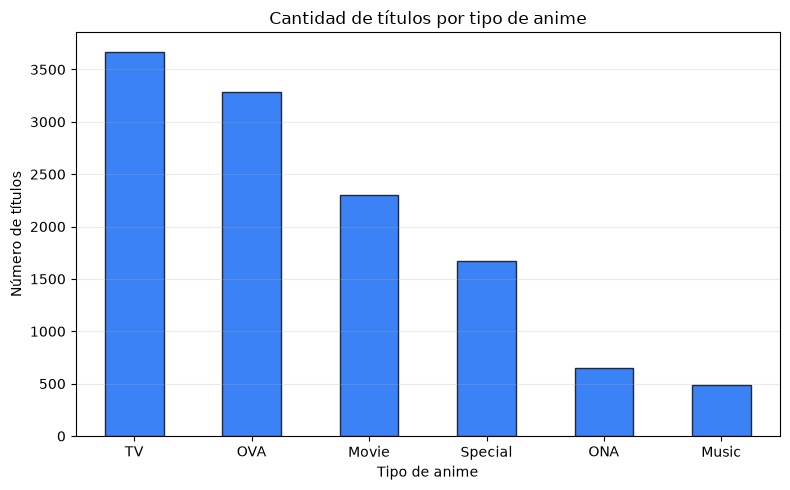

In [18]:
conteo_type_ordenado = df["type"].value_counts()

plt.figure(figsize=(8, 5))
conteo_type_ordenado.plot(
    kind="bar", color="#3B82F6", edgecolor="#1F2937"
)
plt.title("Cantidad de títulos por tipo de anime")
plt.xlabel("Tipo de anime")
plt.ylabel("Número de títulos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

TV (3.671) y OVA (3.285) son los tipos más frecuentes, seguidos por Movie (2.297). Los tres reúnen el **76,70 %** de los títulos del conjunto analítico. Music (488) y ONA (652) son los formatos menos representados.

**Recomendación:** `type` nos sirve para comparar cómo se distribuyen los títulos entre formatos. Sin embargo, la cantidad de títulos no informa por sí sola sobre su consumo; para responder esa pregunta necesitaríamos datos adicionales.

**2) Gráfico circular — proporción de títulos con `members` atípico**

Usamos una variable binaria construida con el criterio IQR: cada título se clasifica como valor atípico superior o como no atípico.

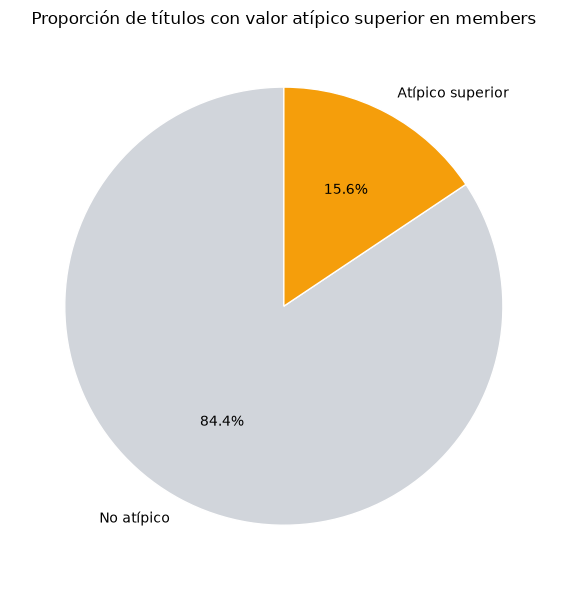

members
False    10180
True      1884
Name: Número de títulos, dtype: int64

In [19]:
conteo_atipicos = es_atipico_members.value_counts().reindex(
    [False, True], fill_value=0
)
etiquetas_atipicos = ["No atípico", "Atípico superior"]
colores_atipicos = ["#D1D5DB", "#F59E0B"]

plt.figure(figsize=(6, 6))
plt.pie(
    conteo_atipicos,
    labels=etiquetas_atipicos,
    autopct="%1.1f%%",
    colors=colores_atipicos,
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Proporción de títulos con valor atípico superior en members")
plt.tight_layout()
plt.show()

display(conteo_atipicos.rename("Número de títulos"))

El gráfico muestra que **15,62 %** de los títulos se clasifica como atípico superior en `members`. Este porcentaje describe la proporción de títulos, no su participación en la variable. El cálculo adicional de la fase de limpieza muestra que ese grupo reúne el **85,44 %** de la suma de `members`.

**Recomendación:** conviene comparar los títulos con valores altos de `members` frente a los demás. Aun así, esta variable debe interpretarse como una aproximación y no como visualizaciones o personas únicas.

**3) Histograma — distribución de `rating`**

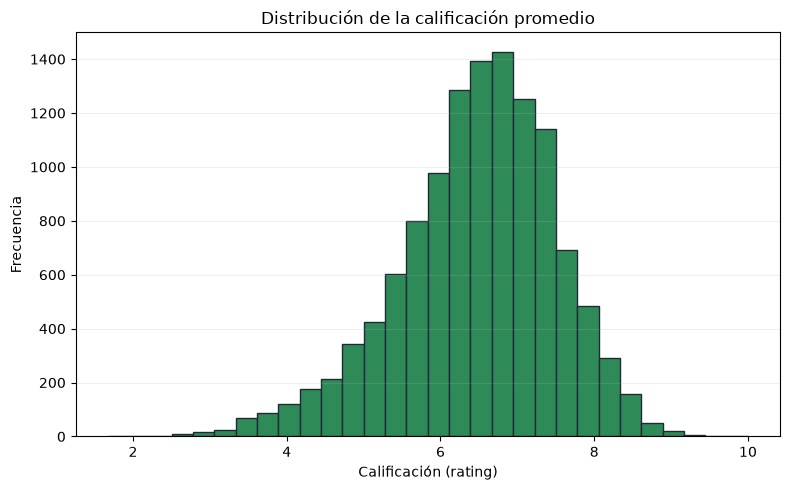

Coeficiente de asimetría: -0.54357


In [20]:
asimetria_rating = df["rating"].skew()

plt.figure(figsize=(8, 5))
plt.hist(
    df["rating"], bins=30, color="#2E8B57", edgecolor="#1F2937"
)
plt.title("Distribución de la calificación promedio")
plt.xlabel("Calificación (rating)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Coeficiente de asimetría:", round(asimetria_rating, 5))

La distribución se concentra alrededor de 6,5 y presenta una cola más larga hacia las calificaciones bajas. El coeficiente de asimetría es **−0,54**, por lo que hablamos de un sesgo negativo moderado, no de una distribución perfectamente simétrica.

**Recomendación:** `rating` ofrece una señal útil, pero su rango central es relativamente estrecho y no conocemos el número de votos. Para comparar títulos sería conveniente complementarlo con esa cantidad de calificaciones, disponible a partir de `rating.csv`, y no usarlo como único criterio.

**4) Diagrama de dispersión — relación entre `rating` y `members`**

Debido al fuerte sesgo de `members`, aplicamos `log1p`, es decir, el logaritmo natural de `members + 1`. También reportamos la correlación en la escala original para conservar el punto de comparación.

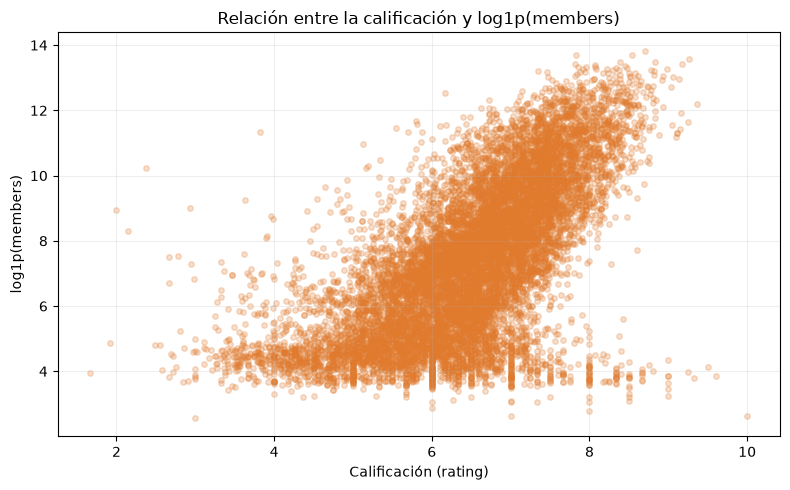

Correlación de Pearson en escala original: 0.38797945850031657
Correlación de Pearson con log1p(members): 0.648254185650229


In [21]:
members_log = np.log1p(df["members"])
correlacion_original = df["rating"].corr(df["members"])
correlacion_log = df["rating"].corr(members_log)

plt.figure(figsize=(8, 5))
plt.scatter(
    df["rating"], members_log, alpha=0.25, s=16, color="#E07A2D"
)
plt.title("Relación entre la calificación y log1p(members)")
plt.xlabel("Calificación (rating)")
plt.ylabel("log1p(members)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Correlación de Pearson en escala original:", correlacion_original)
print("Correlación de Pearson con log1p(members):", correlacion_log)

En la escala original, la correlación de Pearson es **0,39**, una relación positiva de magnitud baja a moderada. Después de transformar `members`, la correlación aumenta a **0,65** y la nube de puntos se vuelve más legible.

Esto indica una asociación positiva dentro del conjunto analítico, pero no permite afirmar que una calificación alta cause una mayor popularidad. Los títulos con `rating` alto y pocos `members` se encuentran en la zona **inferior derecha** del gráfico; son casos que conviene revisar por separado, sin asumir que el promedio de `rating` sea estable.

**Recomendación:** para analizar popularidad conviene transformar `members` y añadir variables que el conjunto de datos no incluye, como antigüedad, disponibilidad o promoción.

**5) Diagrama de caja (`boxplot`) — distribución de `members` en escala original y logarítmica**

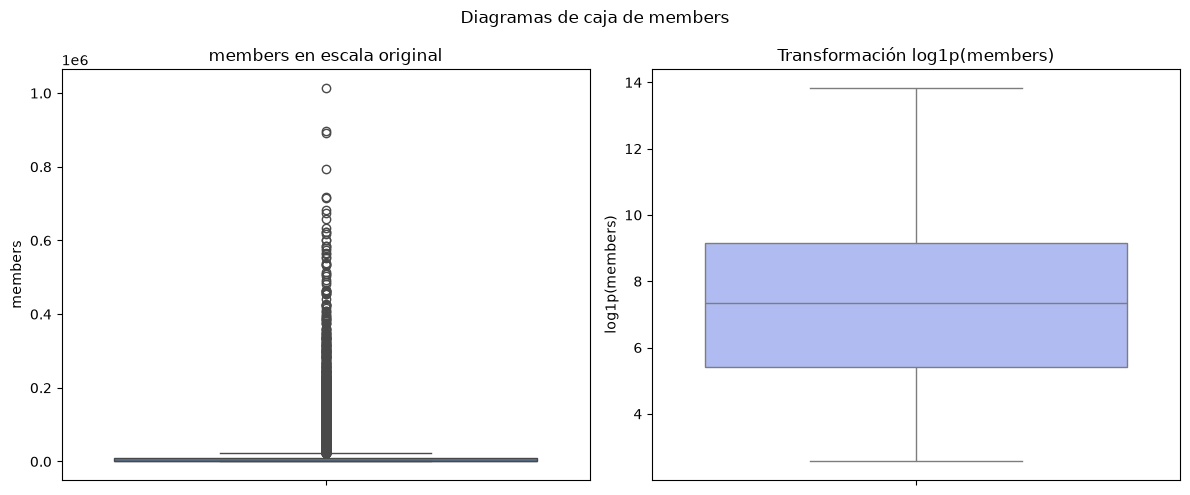

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["members"], color="#4C78A8", ax=axes[0])
axes[0].set_title("members en escala original")
axes[0].set_ylabel("members")
axes[0].set_xlabel("")

sns.boxplot(y=members_log, color="#A5B4FC", ax=axes[1])
axes[1].set_title("Transformación log1p(members)")
axes[1].set_ylabel("log1p(members)")
axes[1].set_xlabel("")

fig.suptitle("Diagramas de caja de members")
plt.tight_layout()
plt.show()

En la escala original, la caja queda comprimida cerca de cero y aparecen numerosos puntos por encima del bigote superior. Esta imagen es coherente con los **1.884** valores atípicos detectados mediante IQR. No hay atípicos inferiores porque el límite calculado es negativo.

El segundo panel no elimina observaciones: transforma la escala para que la zona central sea visible. Allí se aprecia mejor la variación entre los títulos con valores bajos y medios.

**Recomendación:** al modelar o visualizar `members`, conviene evaluar una transformación logarítmica y reportar la mediana (**1.539**) junto con la media (**18.280**), porque la media está influenciada por la cola derecha.

**6) Punto 21 — reemplazo del gráfico de líneas por un segundo diagrama de caja**

`anime.csv` no tiene una variable temporal. Por esa razón, un gráfico de líneas no sería adecuado y usamos la alternativa indicada en el enunciado: comparar `rating` entre los tipos de anime.

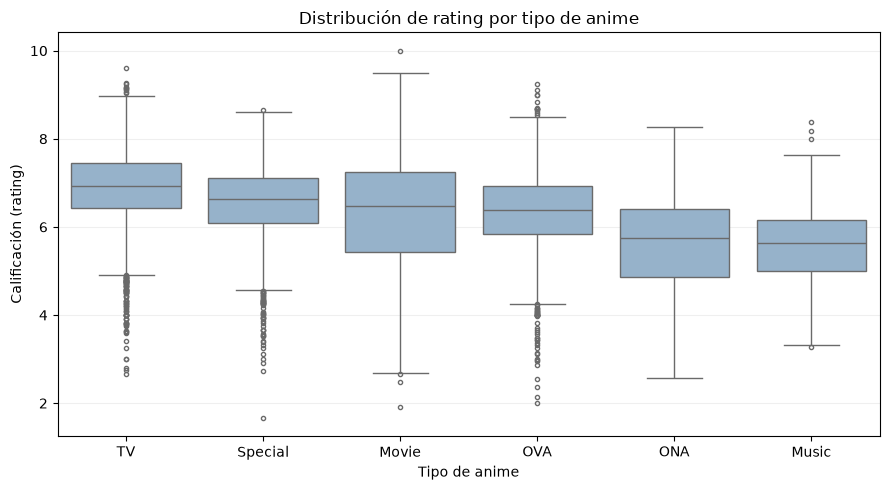

Cuartiles de rating por tipo:


,Q1,Mediana,Q3,IQR
type,,,,
TV,6.440,6.940,7.460,1.020
Special,6.085,6.630,7.110,1.025
Movie,5.420,6.470,7.250,1.830
OVA,5.850,6.380,6.920,1.070
ONA,4.870,5.755,6.412,1.542
Music,5.010,5.625,6.152,1.142


In [23]:
resumen_rating_por_type = (
    df.groupby("type")["rating"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .rename(columns={0.25: "Q1", 0.50: "Mediana", 0.75: "Q3"})
)
resumen_rating_por_type["IQR"] = (
    resumen_rating_por_type["Q3"] - resumen_rating_por_type["Q1"]
)
orden_type_rating = resumen_rating_por_type.sort_values(
    "Mediana", ascending=False
).index

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="type",
    y="rating",
    order=orden_type_rating,
    color="#8DB3D3",
    fliersize=3,
)
plt.title("Distribución de rating por tipo de anime")
plt.xlabel("Tipo de anime")
plt.ylabel("Calificación (rating)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Cuartiles de rating por tipo:")
display(resumen_rating_por_type.loc[orden_type_rating].round(3))

TV tiene la mediana más alta de `rating` (**6,94**), seguida por Special (**6,63**) y Movie (**6,47**). ONA (**5,76**) y Music (**5,63**) presentan las medianas más bajas; Music tiene la menor.

En un diagrama de caja vertical, el IQR se observa en la **altura** de la caja. Movie tiene la mayor dispersión central, con un IQR de **1,83**, seguida por ONA con **1,54**. TV tiene el IQR más pequeño (**1,02**), por lo que sus calificaciones centrales son más compactas.

**Recomendación:** `type` puede servir para segmentar el análisis, pero las distribuciones se superponen. Por eso no sería suficiente para decidir sobre un título específico sin revisar otras variables y el número de calificaciones.

## Fase 5 — Conclusiones

Para cerrar, reunimos cuatro gráficos que resumen los hallazgos principales: cantidad de títulos por tipo, distribución de `rating`, relación entre `rating` y `members` transformado, y distribución de `rating` por tipo.

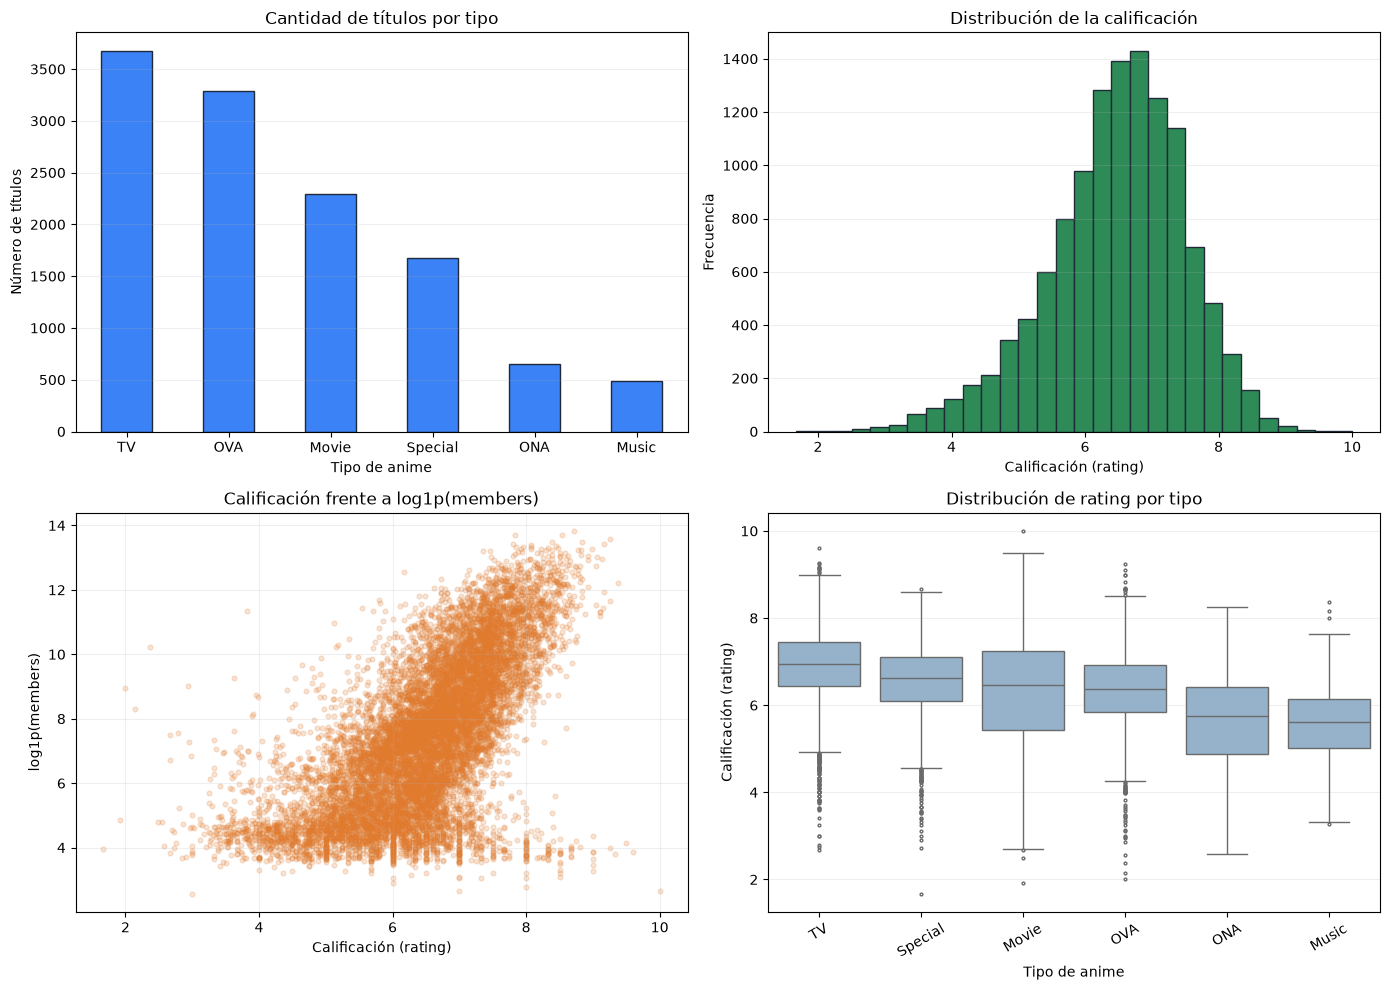

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barras: cantidad de títulos por type
conteo_type_ordenado.plot(
    kind="bar", color="#3B82F6", edgecolor="#1F2937", ax=axes[0, 0]
)
axes[0, 0].set_title("Cantidad de títulos por tipo")
axes[0, 0].set_xlabel("Tipo de anime")
axes[0, 0].set_ylabel("Número de títulos")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].grid(axis="y", alpha=0.2)

# 2. Histograma: distribución de rating
axes[0, 1].hist(
    df["rating"], bins=30, color="#2E8B57", edgecolor="#1F2937"
)
axes[0, 1].set_title("Distribución de la calificación")
axes[0, 1].set_xlabel("Calificación (rating)")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].grid(axis="y", alpha=0.2)

# 3. Dispersión: rating y members transformado
axes[1, 0].scatter(
    df["rating"], members_log, alpha=0.2, s=12, color="#E07A2D"
)
axes[1, 0].set_title("Calificación frente a log1p(members)")
axes[1, 0].set_xlabel("Calificación (rating)")
axes[1, 0].set_ylabel("log1p(members)")
axes[1, 0].grid(alpha=0.2)

# 4. Diagrama de caja: rating por type
sns.boxplot(
    data=df,
    x="type",
    y="rating",
    order=orden_type_rating,
    color="#8DB3D3",
    fliersize=2,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Distribución de rating por tipo")
axes[1, 1].set_xlabel("Tipo de anime")
axes[1, 1].set_ylabel("Calificación (rating)")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Conclusiones generales

**¿Qué aprendimos del conjunto de datos?** En el conjunto analítico predominan los títulos de tipo TV y OVA. TV presenta los mayores promedios de `rating` (6,90) y `members` (43.775), aunque estos resultados son asociaciones descriptivas y no prueban que el formato sea la causa. También encontramos una distribución muy concentrada de `members`: el 15,62 % de títulos clasificado como atípico superior reúne el 85,44 % de la suma de esta variable. Esa suma no equivale a visualizaciones ni a personas únicas.

**¿Qué variables parecen más relevantes?** `members` funciona como una aproximación a popularidad, pero requiere una lectura cuidadosa por su fuerte sesgo y mejora visualmente con `log1p`. `rating` resume la recepción promedio, aunque no conocemos cuántos votos lo sostienen. `type` permite comparar los tipos y `genre` ofrece información multietiqueta que necesitaría una codificación especial. `anime_id` es el identificador único; `name` es una etiqueta descriptiva y puede repetirse.

**¿Qué limpieza fue necesaria?** Excluimos 230 filas sin `type` o `rating` y dejamos explícito que las conclusiones se limitan a los 12.064 registros conservados. Imputamos 188 valores de `episodes` con la mediana de cada `type` y convertimos la columna a entero. Marcamos 47 registros sin género con la etiqueta `Unknown`, corregimos 286 nombres con entidades HTML y comprobamos que no había filas completas ni identificadores duplicados.

**¿Qué relación encontramos entre calificación y popularidad aproximada?** La correlación de Pearson entre `rating` y `members` es 0,39 en la escala original y 0,65 después de aplicar `log1p` a `members`. La asociación es positiva, pero no implica causalidad y puede depender de variables ausentes como antigüedad, disponibilidad o promoción.

**Limitaciones principales.** El archivo no contiene fechas, número de votos, costos, consumo real ni usuarios únicos. Además, las filas excluidas tienen un perfil de faltantes distinto, así que los resultados no deben generalizarse automáticamente a todo el archivo original.

**Preguntas abiertas para un trabajo futuro de aprendizaje automático:**

1. ¿Se puede predecir `rating` a partir de `type` y una codificación multietiqueta de `genre`? Sería necesario separar entrenamiento y prueba y comparar contra una línea base.
2. ¿Cuántas calificaciones individuales sostienen cada promedio? `rating.csv` permitiría calcular ese conteo y construir métricas ajustadas por cantidad de votos.
3. ¿Se puede construir un sistema de recomendación con las interacciones de `rating.csv`? Ese problema requeriría un análisis diferente al EDA de este taller.
4. ¿Cómo cambia la popularidad al incorporar año de estreno, estudio o disponibilidad? Estas variables tendrían que obtenerse de otra fuente y `members` debería modelarse con una transformación adecuada.